In [31]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Setup the notebook.

In [32]:
import h5py
import math
import re
import lm.input.SimulationInput_pb2 as inp
import lm.io.BoundaryConditions_pb2 as bc
import lm.io.ConcentrationsTimeSeries_pb2 as cts
import lm.io.SpeciesTimeSeries_pb2 as sts
from robertslab import ndarray
from robertslab.sfile import SFile
testNames=["eight_sources_eight_sinks"]
test_names_bash_list=" ".join(testNames)
def isclose(a, b, rel_tol=1e-09, abs_tol=0.0):
    return abs(a-b) <= max(rel_tol * max(abs(a), abs(b)), abs_tol)

In [33]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = 9999;

<IPython.core.display.Javascript object>

In [34]:
%%bash
rm -rf tmp && mkdir tmp

### Create the test input files.

In [35]:
def create_eight_sources_eight_sinks(testInputFilename):

    input=inp.SimulationInput()

    # Build the microenv model.
    gridShape=(1,200,200)
    input.microenv_model.initial_time = 0.0;
    input.microenv_model.synchronization_timestep = 0.01;
    input.microenv_model.grid_shape.extend(gridShape)
    input.microenv_model.grid_spacing = 4.0e-6
    input.microenv_model.species_ids.append(0)
    input.microenv_model.diffusion_coefficients.append(1000e-12)
    input.microenv_model.boundaries.axis_specific_boundaries = True
    input.microenv_model.boundaries.x_plus = bc.BoundaryConditions().REFLECTING
    input.microenv_model.boundaries.x_minus = bc.BoundaryConditions().REFLECTING
    input.microenv_model.boundaries.y_plus = bc.BoundaryConditions().LINEAR_GRADIENT
    input.microenv_model.boundaries.y_minus = bc.BoundaryConditions().LINEAR_GRADIENT
    input.microenv_model.boundaries.z_plus = bc.BoundaryConditions().LINEAR_GRADIENT
    input.microenv_model.boundaries.z_minus = bc.BoundaryConditions().LINEAR_GRADIENT
    grid = np.zeros(gridShape)
    ndarray.serializeIntoPbufMessage(input.microenv_model.initial_concentrations.add(), grid)

    # Build the cells.
    input.microenv_model.number_cells = 16
    yi = [ 70, 90,110,130,  70, 90,110,130,  70, 90,110,130,  70, 90,110,130]
    zi = [ 70, 70, 70, 70,  90, 90, 90, 90, 110,110,110,110, 130,130,130,130]
    r1 = [  1,  0,  1,  0,   0,  1,  0,  1,   1,  0,  1,  0,   0,  1,  0,  1]
    r2 = [  0,  1,  0,  1,   1,  0,  1,  0,   0,  1,  0,  1,   1,  0,  1,  0]
    counts = np.zeros((16,3), dtype=np.uint32)
    coords = np.zeros((16,3))
    volume = np.zeros((16,))
    for i in range(0,input.microenv_model.number_cells):
        counts[i,1] = r1[i]
        counts[i,2] = r2[i]
        coords[i,0] = 0.0
        coords[i,1] = yi[i]*4.0e-6
        coords[i,2] = zi[i]*4.0e-6
        volume[i] = 3.35e-14
    ndarray.serializeIntoPbufMessage(input.microenv_model.cell_initial_species_counts, counts)
    ndarray.serializeIntoPbufMessage(input.microenv_model.cell_coordinates, coords)
    ndarray.serializeIntoPbufMessage(input.microenv_model.cell_volume, volume)

    # Write the input to the file.
    file=SFile.fromFilename("%s.sfile"%(testInputFilename), "w")
    file.writeRecord("input", "protobuf:lm.input.SimulationInput", stringData=input.SerializeToString())
    file.close()        

In [36]:
createMethods = {"eight_sources_eight_sinks": create_eight_sources_eight_sinks}
for testName in testNames:
    testInputFilename="tmp/%s.input"%(testName)
    createMethods[testName](testInputFilename)
print "Finished."
pass

Finished.


### Execute the simulations.

In [37]:
%%bash -s "$test_names_bash_list"
sbmlFilename="microenv_source_sink.sbml"
for testName in $1; do
    lmInputFilename=tmp/${testName}.input.lm
    sfileInputFilename=tmp/${testName}.input.sfile
    outputFilename=tmp/${testName}.sfile
    rm -f ${lmInputFilename} && lm_sbml_import ${lmInputFilename} ${sbmlFilename} > ${lmInputFilename}.import.log
    if [[ ${testName} == eight_sources_eight_sinks ]]; then
        lm_setp ${lmInputFilename} writeInterval=1e0 maxTime=1e1 > /dev/null
    else
        echo "Invalid test name: ${testName}"
        continue
    fi
    if [[ ${testName} == *_avx ]]; then
        lmes -r 0 -me -f ${lmInputFilename},${sfileInputFilename} -ff sfile -fo ${outputFilename} -sl lm::avx::GillespieDSolverAVX > ${outputFilename}.simulate.log
    else
        lmes -r 0 -me -f ${lmInputFilename},${sfileInputFilename} -ff sfile -fo ${outputFilename} -sl lm::cme::GillespieDSolver > ${outputFilename}.simulate.log
    fi
done;
echo "Finished."

Finished.


### Define the tests.

In [71]:
def test_eight_sources_eight_sinks(testOutputFilename):

    # Get the grid size and count the entries.
    numberTimes=0
    gridShape=None
    numberCells=0
    numberSpecies=None
    file=SFile.fromFilename(testOutputFilename, "r")
    while True:
        record=file.readNextRecord()
        if record is None: break
        if record.dataType == "protobuf:lm.io.ConcentrationsTimeSeries":
            obj=cts.ConcentrationsTimeSeries()
            obj.ParseFromString(file.readData(record.dataSize))
            numberTimes += obj.times.shape[0]
            if gridShape is None: gridShape = tuple(obj.concentrations[0].shape)
        elif record.dataType == "protobuf:lm.io.SpeciesTimeSeries":
            obj=sts.SpeciesTimeSeries()
            obj.ParseFromString(file.readData(record.dataSize))
            cell = obj.trajectory_id
            numberCells=max(cell+1,numberCells)
            if numberSpecies is None: numberSpecies = obj.counts.shape[1]
        else:
            file.skipData(record.dataSize)
    file.close();    
    if numberTimes != 11: raise Exception("incorrect number of records",numberTimes)
    if gridShape != (1,200,200): raise Exception("incorrect grid shape",gridShape)
    if numberCells != 16: raise Exception("incorrect number of cells",numberCells)
    if numberSpecies != 3: raise Exception("incorrect number of species",numberSpecies)

    # Load the species counts for the cells.
    counts=np.zeros((numberTimes,numberCells,numberSpecies))
    file=SFile.fromFilename(testOutputFilename, "r")
    index={}
    for cell in range(0,numberCells):
        index[cell] = 0
    while True:
        record=file.readNextRecord()
        if record is None: break
        elif record.dataType == "protobuf:lm.io.SpeciesTimeSeries":
            obj=sts.SpeciesTimeSeries()
            obj.ParseFromString(file.readData(record.dataSize))
            cell = obj.trajectory_id
            recordCounts = ndarray.deserializePbufMessage(obj.counts)
            recordTimes = ndarray.deserializePbufMessage(obj.times)
            for i in range(0,recordCounts.shape[0]):
                #if recordTimes[i] != times[index[cell]]: print "Consistency error in cell %d: %e != %e"%(cell,recordTimes[i],times[index[cell]])
                counts[index[cell],cell,:] = recordCounts[i]
                index[cell] += 1
        else:
            file.skipData(record.dataSize)
    file.close();
    
    # Load the concentrations.
    times=np.zeros((numberTimes,), dtype=float)
    grids=np.zeros((numberTimes,)+gridShape, dtype=float)
    file=SFile.fromFilename(testOutputFilename, "r")
    index=0
    while True:
        record=file.readNextRecord()
        if record is None: break
        if record.dataType == "protobuf:lm.io.ConcentrationsTimeSeries":
            obj=cts.ConcentrationsTimeSeries()
            obj.ParseFromString(file.readData(record.dataSize))
            recordTimes = ndarray.deserializePbufMessage(obj.times)
            for j in range(0,recordTimes.shape[0]):
                times[index] = recordTimes[j]
                grids[index,:,:,:] = ndarray.deserializePbufMessage(obj.concentrations[j])
                index += 1
        else:
            file.skipData(record.dataSize)
    file.close();
    if times.shape != (11,): raise Exception("incorrect number of times",times.shape)
    if grids.shape != (11,1,200,200): raise Exception("incorrect number of grids",grids.shape)
        
    # Plot the output.
    comparisonIndices=np.linspace(0,times.shape[0]-1,5, dtype=int)
    rows=1
    cols=comparisonIndices.shape[0]
    print cols
    matplotlib.rcParams.update({'font.size': 10, "figure.figsize": (20,3*rows)})
    for i,index in enumerate(comparisonIndices):
        subplot(rows,cols,i+1)
        imshow(grids[index,0,:,:], interpolation='none', aspect=1, origin='lower', vmin=0, vmax=1e-8)
        cb=colorbar(label="c"); cb.ax.set_aspect(5)
        xlabel(r"x"); ylabel("y"); title("Sim t=%0.3f s"%times[index])

    #imshow(log10(grids[:,:]), interpolation='none', aspect=0.03, origin='upper', vmin=-12, vmax=-6)
    #cb=colorbar(label="c"); cb.ax.set_aspect(5)
    #xlabel("x"); ylabel("Timestep"); title(r"Axis=%s, Boundary=%s"%(axis,bc.BoundaryConditions().BoundaryConditionsType.Name(boundary)))
    
    # Check the output.


### Run the tests.

5
[eight_sources_eight_sinks]                                  : passed.


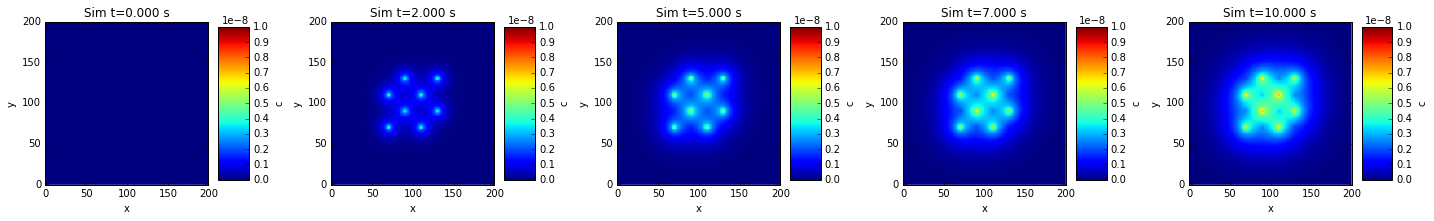

In [72]:
testMethods = {"eight_sources_eight_sinks": test_eight_sources_eight_sinks}
for testName in testNames:
    try:
        testOutputFilename="tmp/%s.sfile"%(testName)
        testMethods[testName](testOutputFilename)
    except Exception as e:
        print "%-60s : FAILED with:"%("["+testName+"]"),e
    except:
        print "%-60s : FAILED with: Unknown exception"%("["+testName+"]")
    else:
        print "%-60s : passed."%("["+testName+"]")
    plt.tight_layout()
    plt.show()
pass

In [ ]:
%%bash
rm -rf tmp

# Regression tests for a set of sources and sinks.

### Loop through the output file to get some sizes.

In [16]:
import re
from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts
import lm.io.SpeciesTimeSeries_pb2 as sts

# Set the filename.
dirname="data/1"
filename="%s/output.sfile"%dirname


print "Finished processing, number of time points was: ",numberTimes,", grid shape was: ",gridShape,", number of cells was: ",numberCells,", number of species was: ",numberSpecies

Finished processing, number of time points was:  1001 , grid shape was:  (1, 200, 200) , number of cells was:  16 , number of species was:  3


### Load the concentration time series.

In [17]:
print "Finished loading."
pass

Finished loading.


### Load the cell time series.

In [18]:
# Load the records for this replicate.
print "Finished loading."
pass

Finished loading.


### Plot the total mass in the diffusion volume as a function of time.

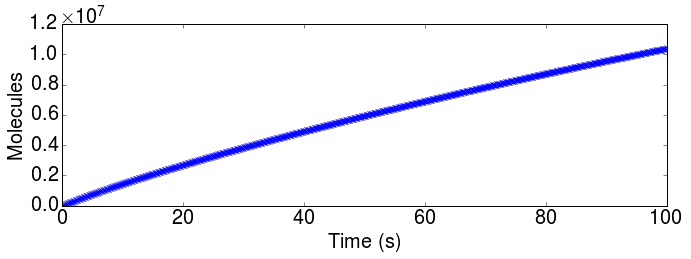

In [19]:
screen_style()
matplotlib.rcParams.update({"figure.figsize": (10,4)})
plotIndex=1
mass=np.sum(grids, (1,2,3))
plot(times, mass*NA*(gridSpacing**3)*1000, 'x')
xlabel("Time (s)"); ylabel("# Molecules");
plt.tight_layout()
pass

### Plot the concentrations at a specific frame of the simulation.

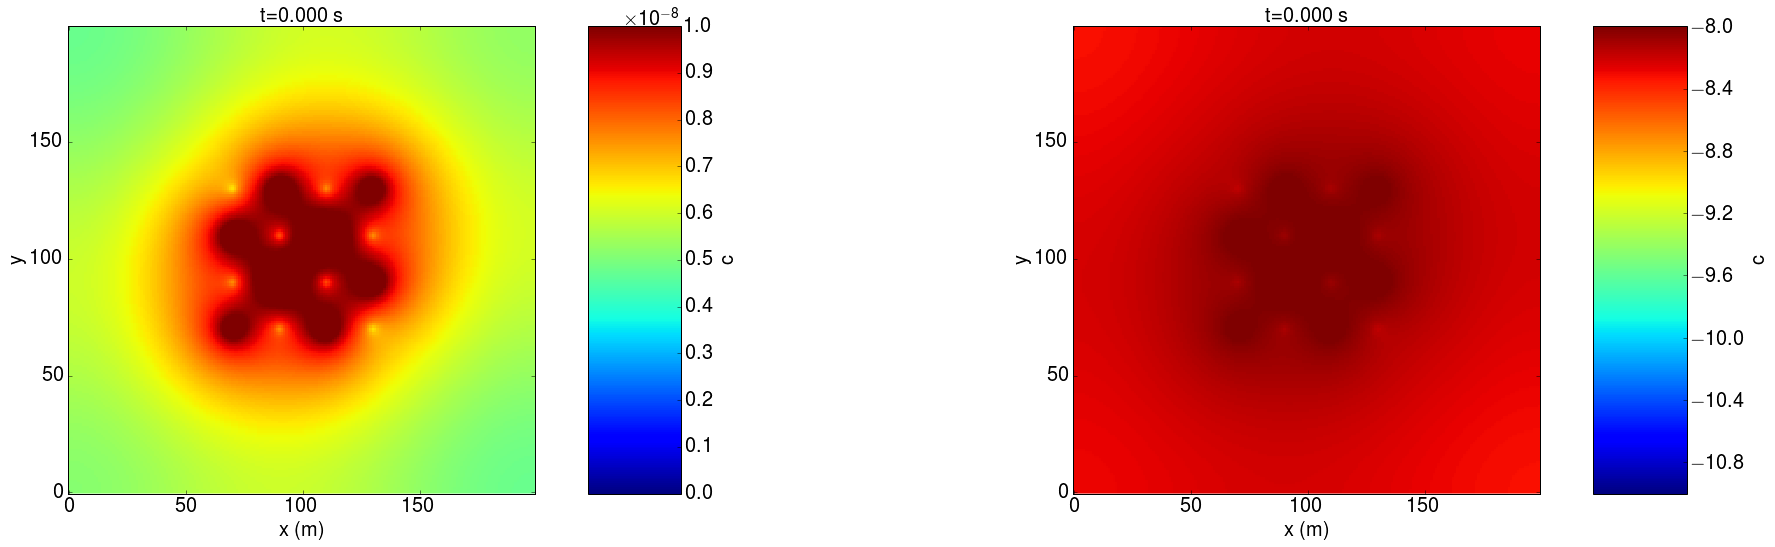

In [20]:
screen_style()
matplotlib.rcParams.update({"figure.figsize": (30,8)})
subplot(1,2,1)
imshow((grids[-1,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=0, vmax=1e-8)
cb=colorbar(label="c"); cb.ax.set_aspect(5)
xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
subplot(1,2,2)
imshow(log10(grids[-1,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=-11, vmax=-8)
cb=colorbar(label="c"); cb.ax.set_aspect(5)
xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
plt.tight_layout()
pass

### Plot the concentration vs time.

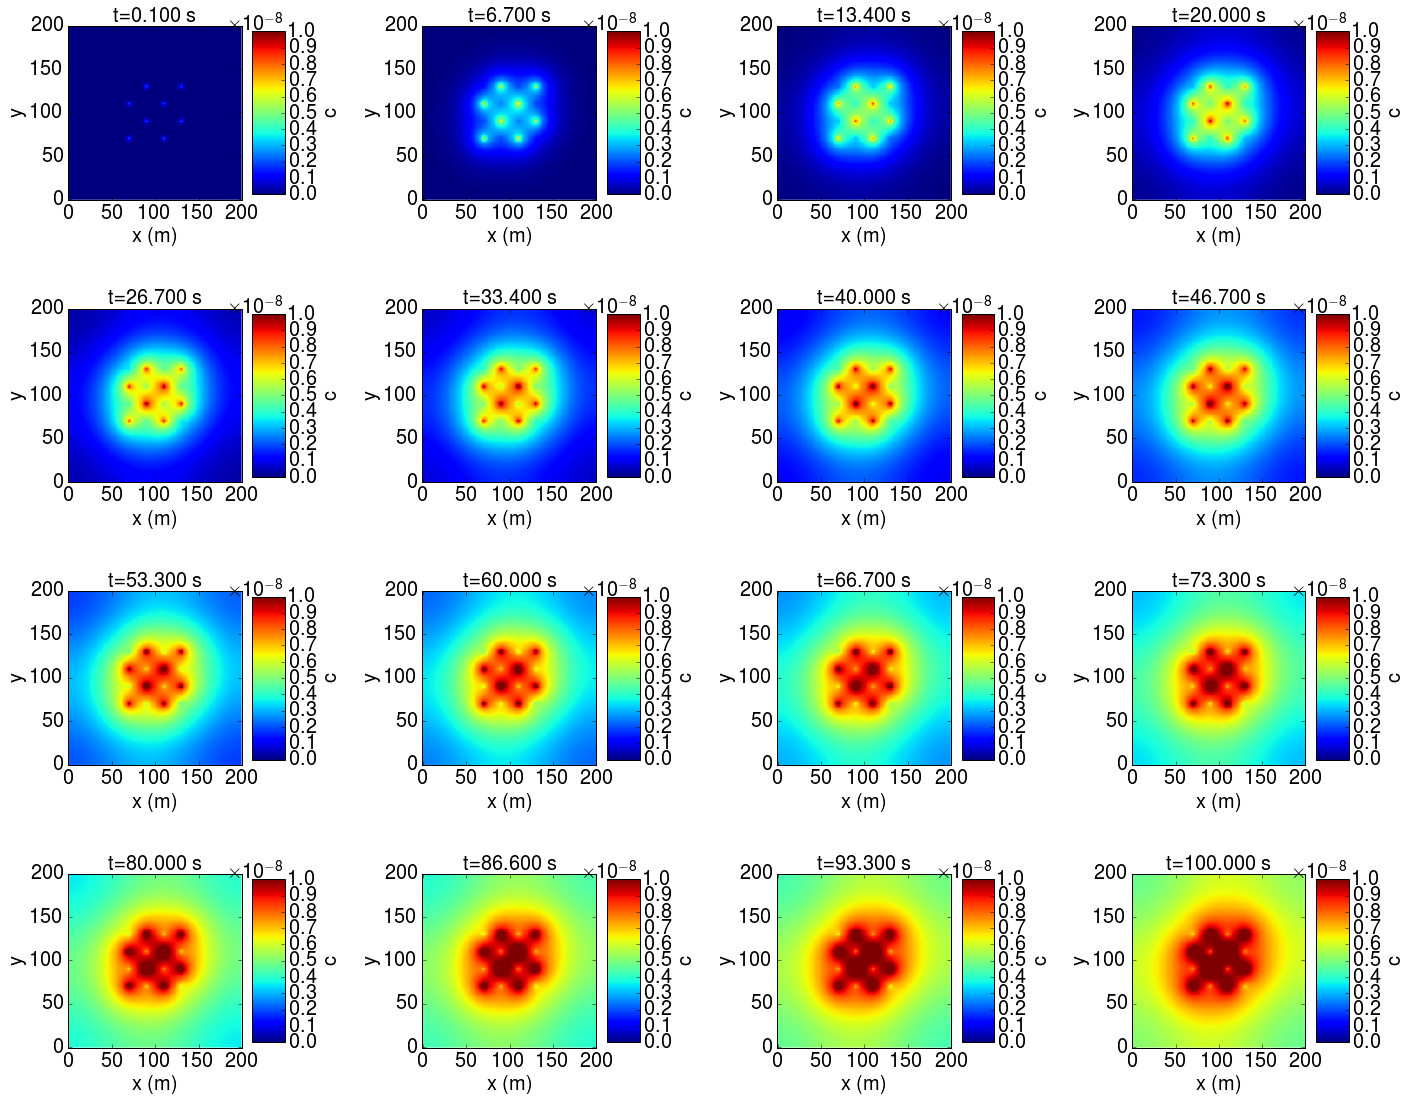

In [22]:
screen_style()
rows=4
cols=4
matplotlib.rcParams.update({"figure.figsize": (20,4*rows)})
plotIndex=1
for plotIndex,i in enumerate(np.linspace(1,times.shape[0]-1,rows*cols, dtype=int)):
    subplot(rows,cols,plotIndex+1)
    #imshow(log10(grids[i,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=-11, vmax=-8)
    imshow((grids[i,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=0, vmax=1e-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
plt.tight_layout()
pass

### Plot the cell species counts vs time.

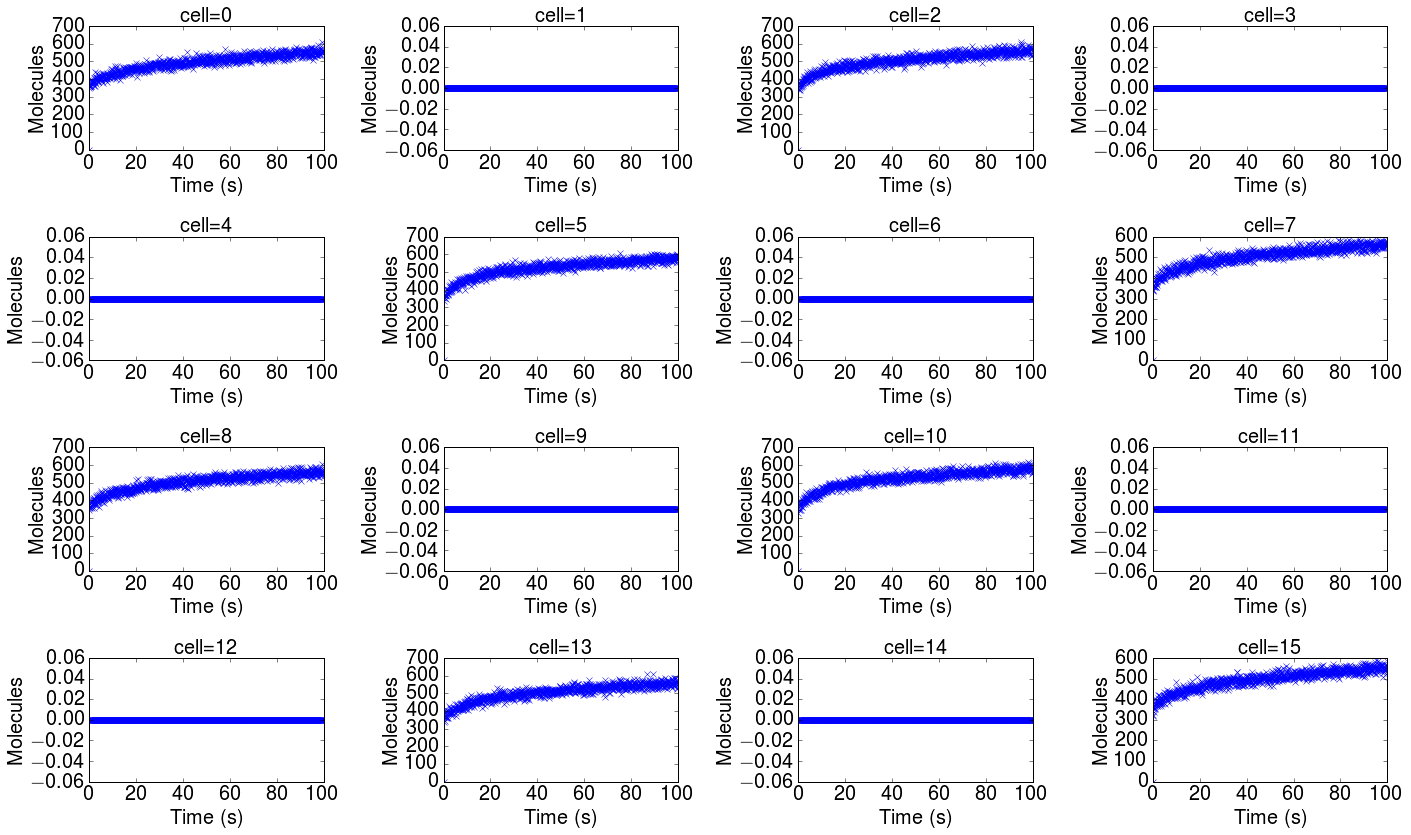

In [23]:
screen_style()
cols=4
rows=ceil(counts.shape[1]/cols)
matplotlib.rcParams.update({"figure.figsize": (20,3*rows)})
for i in range(0,counts.shape[1]):
    subplot(rows,cols,i+1)
    plot(times, counts[:,i,0], 'x')
    xlabel("Time (s)"); ylabel("# Molecules"); title("cell=%d"%i)
plt.tight_layout()
pass